# Beam on an Elastic (Winkler) Foundation

A **member** can rest on a **Winkler foundation** — a continuous bed of springs of stiffness $k_f$ (the modulus of subgrade reaction, per unit length of beam) that pushes back in proportion to the local deflection, $q(x) = -k_f\,v(x)$. This models strip and raft footings, railway track, and pipelines.

> **"Member" and "span" mean the same thing.** PyCBA builds a beam from *members*, added with `add_member` (or equivalently `add_span` — the two are aliases for the element between two nodes). A member carrying a foundation is automatically *meshed* into many short Euler–Bernoulli **sub-elements** and condensed back to its two end nodes — a "super-element", the same internal-meshing pattern the [nonlinear analysis](nonlinear.ipynb) uses. The meshing is invisible: the member still has just two nodes, so reactions, plotting and influence lines are unchanged.

Pass `kf=` to `BeamAnalysis` (a scalar for every member, or one value per member). The mesh density defaults to the foundation characteristic length

$$ \lambda = \left(\frac{4EI}{k_f}\right)^{1/4}. $$

This first version supports prismatic, fixed-fixed members (no `GAv`) carrying UDL, point and partial-UDL loads.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pycba as cba

## Example 1 - Validation against Hetényi

For a long member ($L \gg \lambda$) under a central point load $P$, Hetényi's infinite-beam solution gives the deflection and moment under the load as

$$ v_0 = \frac{P\beta}{2k_f}, \qquad M_0 = \frac{P}{4\beta}, \qquad \beta = \frac{1}{\lambda} = \left(\frac{k_f}{4EI}\right)^{1/4}. $$

We model a free–free member (the foundation alone supports it). Rendering the model with `plot_beam()` shows the member resting on its foundation — the row of springs on hatched ground — with the applied load.

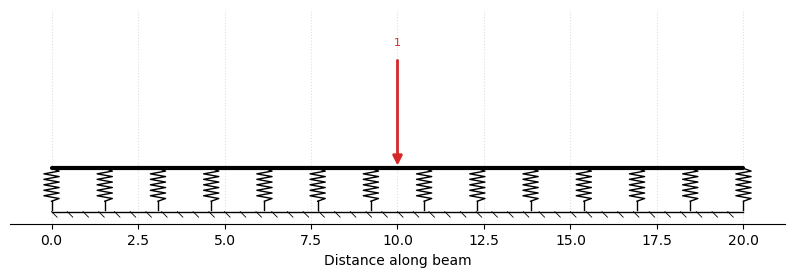

In [2]:
L, EI, kf, P = 20.0, 1.0, 4.0, 1.0      # lambda = 1 -> L/lambda = 20 (long)
beta = (kf / (4 * EI)) ** 0.25

ba = cba.BeamAnalysis([L], EI, [0, 0, 0, 0], kf=kf)   # free-free member on a foundation
ba.add_pl(i_member=1, p=P, a=L / 2)
ba.plot_beam(units="none");                            # render the model

under the load:  v0 = -0.1250  (Hetenyi -0.1250)
                 M0 = 0.2494   (Hetenyi 0.2500)


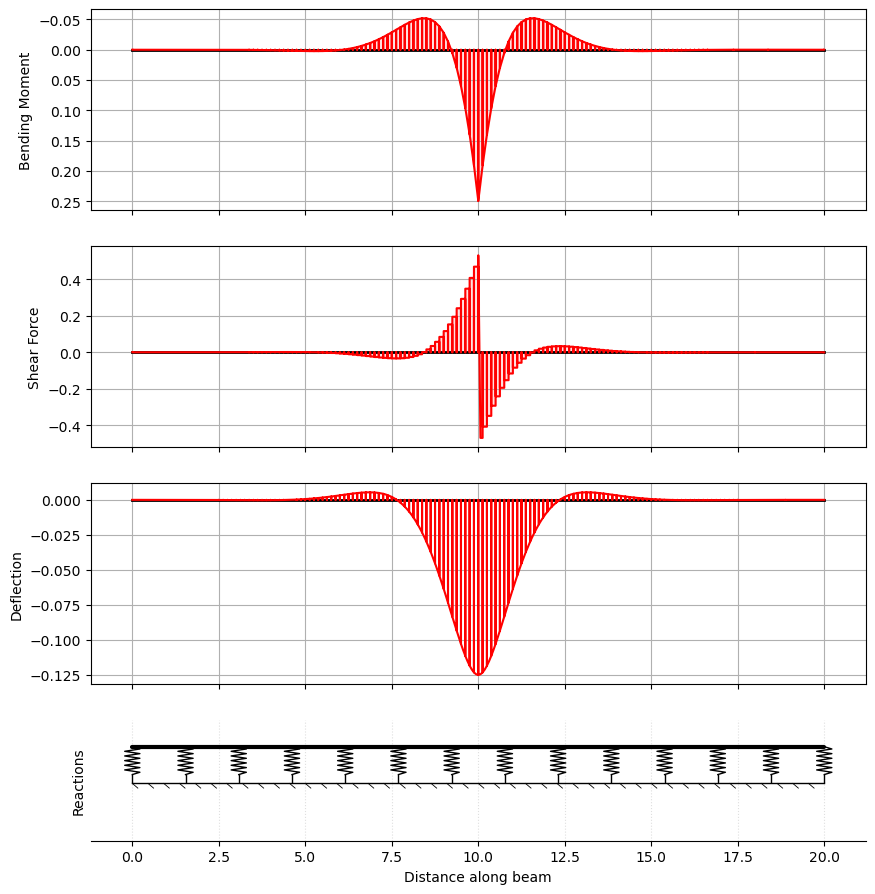

In [3]:
ba.analyze()
res = ba.beam_results.results

i = np.argmin(np.abs(res.x - L / 2))
print(f"under the load:  v0 = {res.D[i]:+.4f}  (Hetenyi {-P*beta/(2*kf):+.4f})")
print(f"                 M0 = {np.max(np.abs(res.M)):.4f}   (Hetenyi {P/(4*beta):.4f})")

ba.plot_results(show_beam=False, units="none");

## Example 2 - A strip footing

A reinforced-concrete strip footing carries two column loads on soil with a modulus of subgrade reaction $k_f$. The footing member is free at both ends — the soil carries the loads. We first render the model (the footing on its elastic foundation with the two column loads), then read the bending moment and the settlement (and hence the bearing pressure $k_f\,|v|$) from the analysis.

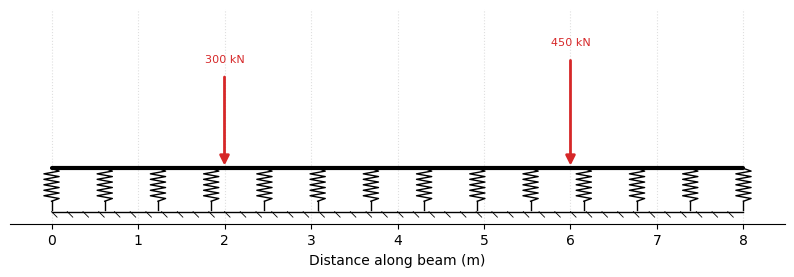

In [4]:
L = 8.0                  # m, footing length
EI = 1.0e5               # kNm^2 (footing flexural rigidity)
kf = 2.0e4               # kN/m per m (subgrade modulus x footing width)

footing = cba.BeamAnalysis([L], EI, [0, 0, 0, 0], kf=kf)
footing.add_pl(i_member=1, p=300, a=2.0)   # column 1
footing.add_pl(i_member=1, p=450, a=6.0)   # column 2
footing.plot_beam();                      # render the model

max hogging/sagging moment: -49.2 / 191.1 kNm
max bearing pressure: 123.6 kN/m


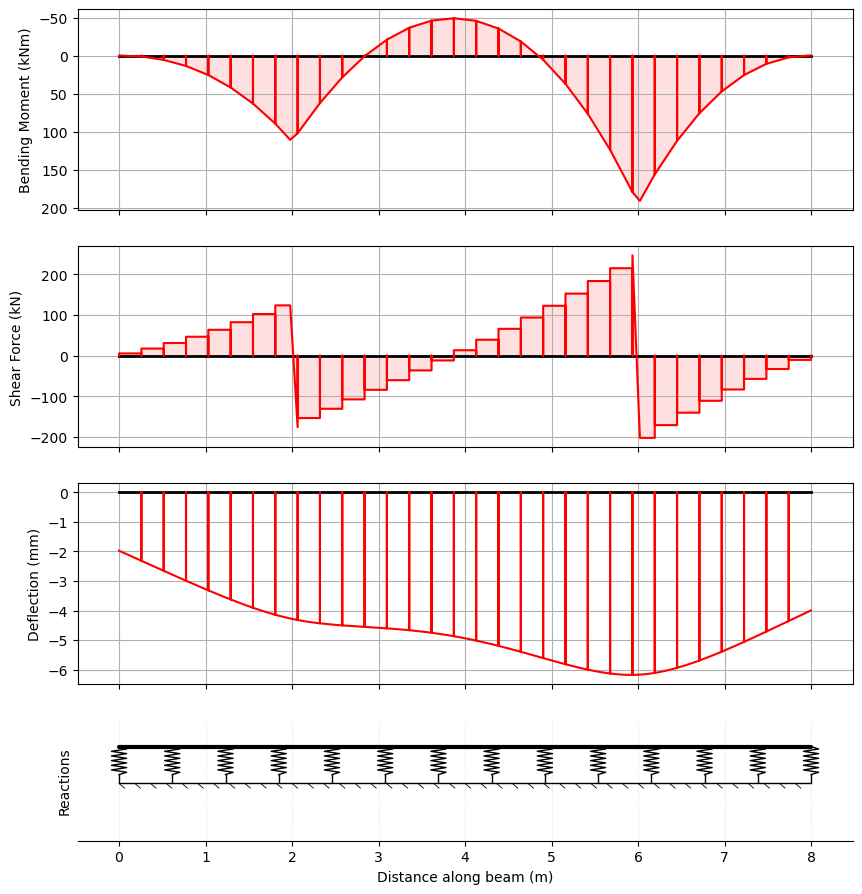

In [5]:
footing.analyze()
res = footing.beam_results.results

pressure = kf * (-res.D)                  # bearing pressure
print(f"max hogging/sagging moment: {res.M.min():.1f} / {res.M.max():.1f} kNm")
print(f"max bearing pressure: {pressure.max():.1f} kN/m")

footing.plot_results(show_beam=False);

## Example 3 - A railway bridge with ballasted approaches

This combines a foundation with ordinary supports and a moving load. A train runs along **ballasted track** — the rail on its ballast/subgrade, the classic [Hetényi (1946)](../references.md) beam-on-elastic-foundation — onto a **two-span** bridge where the track is **directly fixed** to the deck (no ballast, so the deck spans between the abutments and a central pier), and off again onto ballast:

```
0 ─ approach (foundation) ─ 10 ═ span 1 ═ 22 (pier) ═ span 2 ═ 34 ─ departure (foundation) ─ 44
 (free)               (abutment)               (pier)            (abutment)             (free)
```

We model it as one continuous member: a foundation (`kf`) on the approaches only, pinned abutments and a central pier under the bridge, and the stiffer bridge-deck `EI` over the two spans. Then we run the AS5100.2 **300LA** rail load model (`VehicleLibrary.AU.get_la_rail`) across it and envelope the effects.

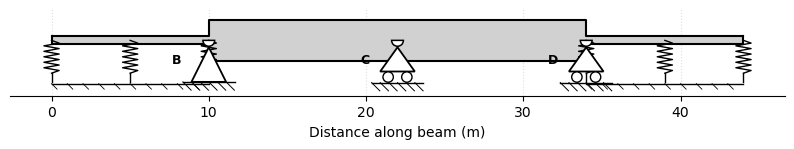

In [6]:
# approach | abutment | span 1 | pier | span 2 | abutment | departure
L  = [10.0, 12.0, 12.0, 10.0]               # m
EI = [1.3e4, 2.0e6, 2.0e6, 1.3e4]           # track on ballast, two bridge spans, track on ballast
kf = [4.0e4, None, None, 4.0e4]             # ballast (Winkler) under the approaches only
R  = [0, 0,  -1, 0,  -1, 0,  -1, 0,  0, 0]  # free | abutment | pier | abutment | free

ba = cba.BeamAnalysis(L, EI, R, kf=kf)
ba.plot_beam();                             # ballasted approaches + the two-span bridge deck

span sagging Mmax:  2445 kNm at x = 15.3 m
pier hogging Mmin:  -2639 kNm at x = 22.0 m
reactions: abutment 1162, pier 1715, abutment 1023 kN


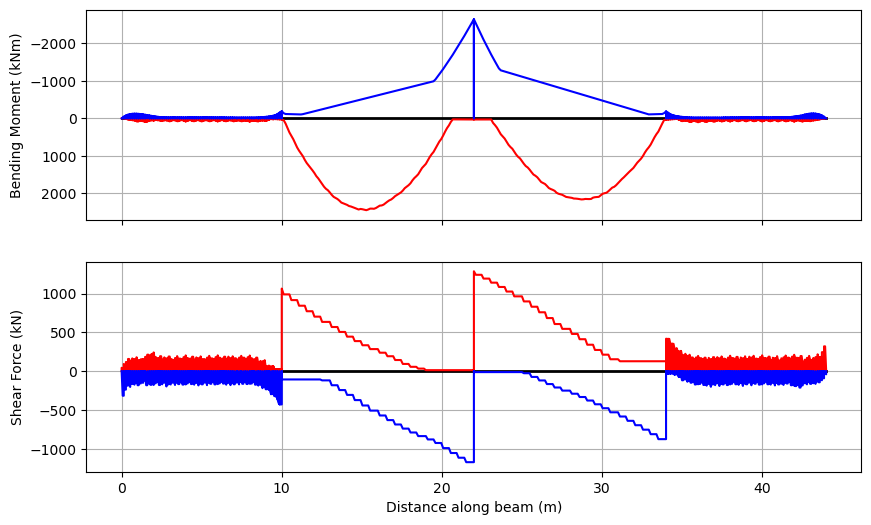

In [7]:
veh = cba.VehicleLibrary.AU.get_la_rail(axle_group_count=4)   # AS5100.2 300LA
bridge = cba.BridgeAnalysis(ba, veh)
env = bridge.run_vehicle(step=0.5)
cv = bridge.critical_values(env)

print(f"span sagging Mmax:  {cv['Mmax']['val']:.0f} kNm at x = {cv['Mmax']['at']:.1f} m")
print(f"pier hogging Mmin:  {cv['Mmin']['val']:.0f} kNm at x = {cv['Mmin']['at']:.1f} m")
print(f"reactions: abutment {cv['Rmax0']['val']:.0f}, pier {cv['Rmax1']['val']:.0f}, "
      f"abutment {cv['Rmax2']['val']:.0f} kN")

env.plot();

Each span carries a sagging envelope, with **hogging over the central pier** — the response of a two-span continuous bridge — while the **ballasted approaches** show the small, *oscillating* signature of a beam on an elastic foundation, each axle riding in its own deflection bowl. The foundation, the abutments and the pier all act together in the one model. We can also see the train at its worst position for span sagging:

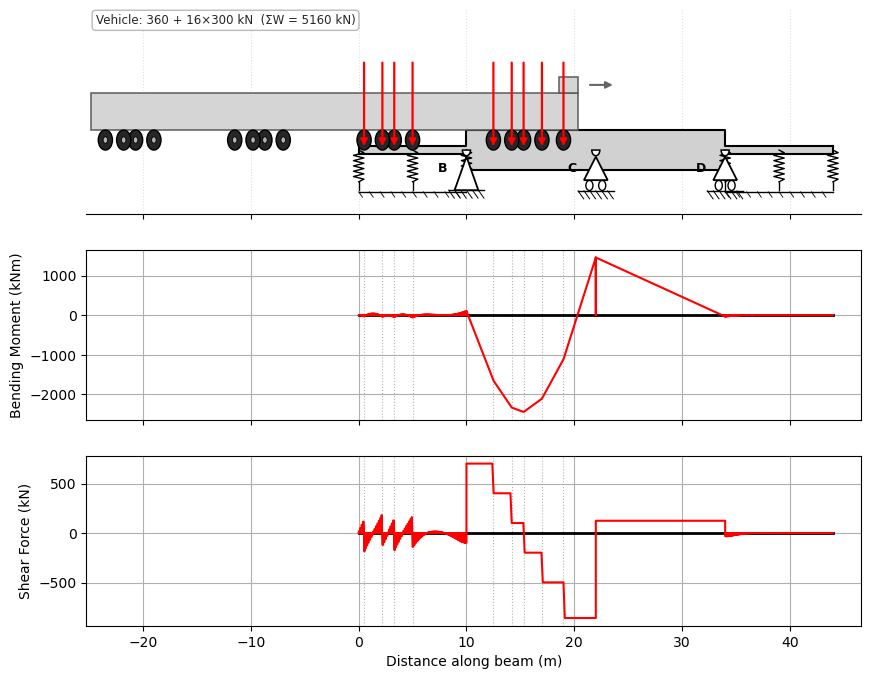

In [8]:
bridge.plot_static(cv["Mmax"]["pos"][0]);   # the 300LA at the critical position

> **A linear, no-tension idealisation.** A real ballast/subgrade carries no tension, and run-on slabs in fact span a settlement *trough* behind the abutment rather than resting on a continuous bed ([O'Brien, Keogh & O'Connor (2014), *Bridge Deck Analysis* §4.5](../references.md)). The linear, bidirectional Winkler foundation used here therefore over-estimates effects in any uplift zones; a no-tension foundation would relieve them.

## Notes

- `kf` may be set per member, so a beam can rest on a foundation over part of its length and be conventionally supported elsewhere (the schematic draws the springs only under the foundation members).
- The mesh density defaults to the characteristic length; see `pycba.foundation.auto_subdivisions`.
- Current support: prismatic, fixed-fixed members without shear flexibility (`GAv`), carrying UDL, point and partial-UDL loads. Other combinations raise a clear `NotImplementedError`.